# Analyse Exploratoire

### Import des modules

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno # librairie pour identifier les données manquantes
import statsmodels.api as sm

In [107]:
pd.set_option('display.max_columns', None)  # Affiche toutes les colonnes

pd.set_option('display.max_rows', None) # Affiche toutes les lignes

### Analyse Exploratoire

In [108]:
building_consumption = pd.read_csv('data/2016_Building_Energy_Benchmarking.csv')

In [109]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head(1)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.6122,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.5,189.0,7226362.5,7456910.0,2003882.0,1156514.25,3946027.0,12764.5293,1276453.0,False,NaN,Compliant,NaN,249.98,2.83


Types des colonnes :
OSEBuildingID                        int64
DataYear                             int64
BuildingType                           str
PrimaryPropertyType                    str
PropertyName                           str
Address                                str
City                                   str
State                                  str
ZipCode                            float64
TaxParcelIdentificationNumber          str
CouncilDistrictCode                  int64
Neighborhood                           str
Latitude                           float64
Longitude                          float64
YearBuilt                            int64
NumberofBuildings                  float64
NumberofFloors                       int64
PropertyGFATotal                     int64
PropertyGFAParking                   int64
PropertyGFABuilding(s)               int64
ListOfAllPropertyUseTypes              str
LargestPropertyUseType                 str
LargestPropertyUseTypeGFA        

<Axes: >

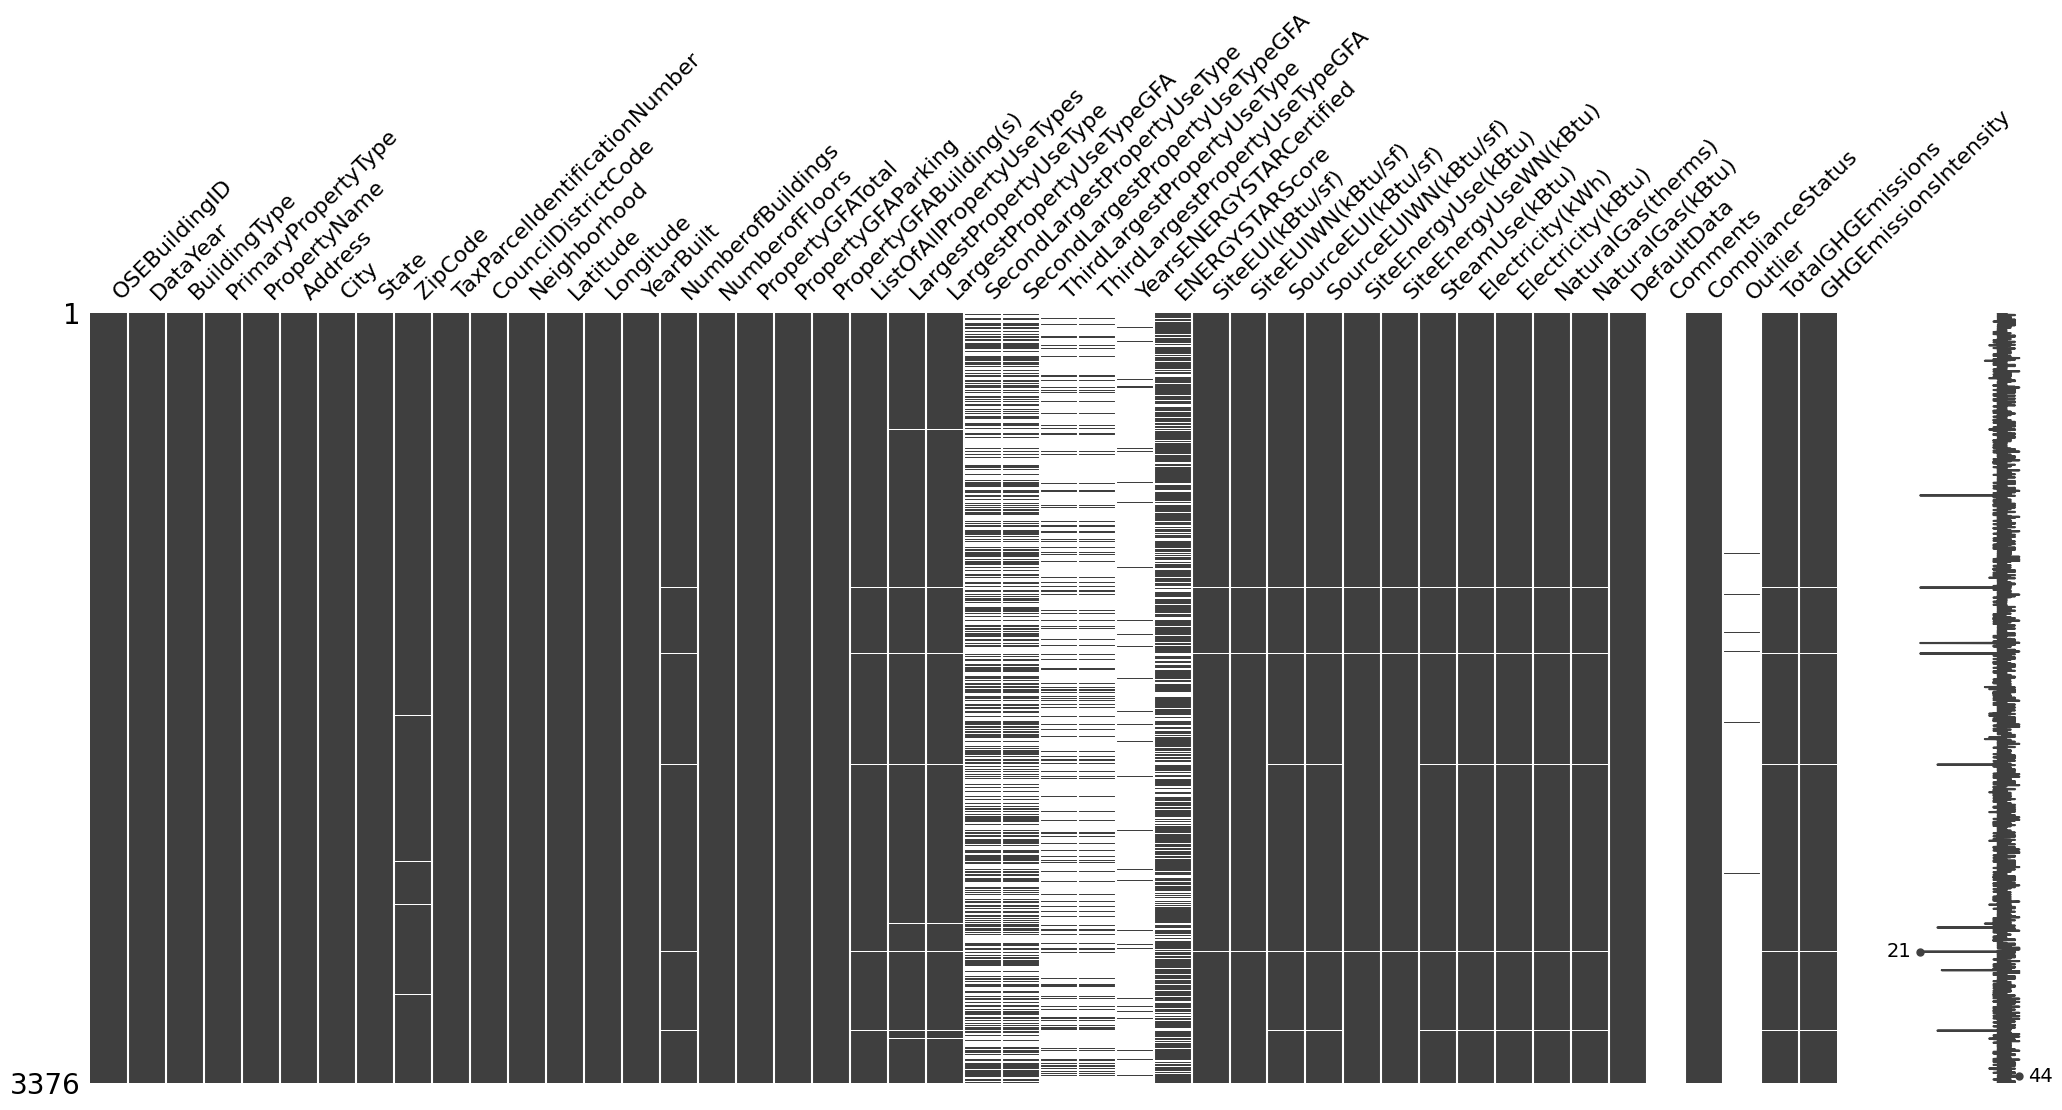

In [110]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
%matplotlib inline

# Afficher le type de chaque colonne
print("Types des colonnes :")
print(building_consumption.dtypes)

# Afficher la matrice de valeurs manquantes
nb_lines = building_consumption.shape[0]
msno.matrix(building_consumption.sample(nb_lines))

In [111]:
# Affiche tous les types de bâtiments
buildingtype_uniques = building_consumption['BuildingType'].unique()
df_uniques = pd.DataFrame(buildingtype_uniques, columns=['BuildingType'])
print(df_uniques)

           BuildingType
0        NonResidential
1    Nonresidential COS
2  Multifamily MR (5-9)
3     SPS-District K-12
4                Campus
5  Multifamily LR (1-4)
6  Multifamily HR (10+)
7     Nonresidential WA


In [112]:
# Afficher le nombre de lignes avant le filtre
print(f"Nombre de lignes avant le filtre : {len(building_consumption)}")

# Garder les lignes avec les bâtiments non destinés à l'habitation
# Liste des types de bâtiments non résidentiels
non_residentiel = [
    "NonResidential",
    "Nonresidential COS",
    "SPS-District K-12",
    "Campus",
    "Nonresidential WA"
]

# Filtrer le DataFrame
building_consumption_non_residentiel = building_consumption[
    building_consumption['BuildingType'].isin(non_residentiel)
]

# Afficher le nombre de lignes après le filtre
print(f"Nombre de lignes après le filtre : {len(building_consumption_non_residentiel)}")

Nombre de lignes avant le filtre : 3376
Nombre de lignes après le filtre : 1668


In [113]:
# Supprimer les bâtiments considérés comme des outliers
# Afficher le nombre de lignes avant le filtre
print(f"Nombre de lignes avant le filtre : {len(building_consumption_non_residentiel)}")

# Filtrer pour garder les lignes où 'Outlier' est vide ou NaN
building_consumption_sans_outliers = building_consumption_non_residentiel[
    building_consumption_non_residentiel['Outlier'].isna()
]

# Afficher le nombre de lignes après le filtre
print(f"Nombre de lignes après le filtre : {len(building_consumption_sans_outliers)}")

Nombre de lignes avant le filtre : 1668
Nombre de lignes après le filtre : 1651


In [114]:
# Garder les bâtiments conformes aux obligations réglementaires de reporting énergétique
# Afficher le nombre de lignes avant le filtre
print(f"Nombre de lignes avant le filtre : {len(building_consumption_sans_outliers)}")

# Filtrer pour garder les lignes où 'ComplianceStatus' est "Compliant" ou "Error - Correct Default Data"
building_consumption_compliant = building_consumption_sans_outliers[
    building_consumption_sans_outliers['ComplianceStatus'].isin(["Compliant", "Error - Correct Default Data"])
]

# Afficher le nombre de lignes après le filtre
print(f"Nombre de lignes après le filtre : {len(building_consumption_compliant)}")

Nombre de lignes avant le filtre : 1651
Nombre de lignes après le filtre : 1634


# Colonnes PERTINENTES (Features explicatives)

*Variables de taille :*
* PropertyGFATotal (*⚠️ est égal à PropertyGFABuilding(s) + PropertyGFAParking*)
* PropertyGFABuilding(s)
* PropertyGFAParking (*⚠️ ne consomme pas d'énergie*)
* NumberofFloors
* NumberofBuildings

*Variables d’usage :*
* PrimaryPropertyType
* BuildingType
* ListOfAllPropertyUseTypes
* LargestPropertyUseType
* LargestPropertyUseTypeGFA
* SecondLargestPropertyUseType      (*⚠️ Peu de données*)
* SecondLargestPropertyUseTypeGFA   (*⚠️ Peu de données*)
* ThirdLargestPropertyUseType       (*⚠️ Peu de données*)
* ThirdLargestPropertyUseTypeGFA    (*⚠️ Peu de données*)

*Variables temporelles :*
* YearBuilt

*Variables géographiques :*
* Latitude
* Longitude
* Neighborhood
* ZipCode
* CouncilDistrictCode

*Colonnes CIBLES :*
* TotalGHGEmissions
* SiteEnergyUse(kBtu)

# Colonnes À EXCLURE (Data Leakage)
* SiteEUI(kBtu/sf)
* SiteEUIWN(kBtu/sf)
* SourceEUI(kBtu/sf)
* SourceEUIWN(kBtu/sf)
* SiteEnergyUseWN(kBtu)
* SteamUse(kBtu)
* Electricity(kWh)
* Electricity(kBtu)
* NaturalGas(therms)
* NaturalGas(kBtu)
* ENERGYSTARScore
* YearsENERGYSTARCertified
* GHGEmissionsIntensity

*Les garder fausserait le modèle car elles sont directement corrélées aux cibles.*

In [115]:
# Garder les colonnes pertinentes
building_consumption_usefull = building_consumption_compliant[[
'YearBuilt',
'NumberofBuildings',
'NumberofFloors',
'PropertyGFABuilding(s)',

'PrimaryPropertyType',
'ListOfAllPropertyUseTypes',
'LargestPropertyUseType',
'LargestPropertyUseTypeGFA',

'Latitude',
'Longitude',
'ZipCode',
'CouncilDistrictCode',

'TotalGHGEmissions',  # target CO2
'SiteEnergyUse(kBtu)' # target énergie
]]

In [116]:
# Afficher le nombre de lignes avant suppression
nb_lignes_avant = len(building_consumption_usefull)
print(f"Nombre de lignes avant suppression des valeurs vides : {nb_lignes_avant}")

# Supprimer les lignes avec des valeurs vides dans n'importe quelle colonne
building_consumption_cleaned = building_consumption_usefull.dropna()

# Afficher le nombre de lignes après suppression
nb_lignes_apres = len(building_consumption_cleaned)
print(f"Nombre de lignes après suppression des valeurs vides : {nb_lignes_apres}")

Nombre de lignes avant suppression des valeurs vides : 1634
Nombre de lignes après suppression des valeurs vides : 1614


In [117]:
# Liste des colonnes à analyser
colonnes_num = ['YearBuilt',
'NumberofBuildings',
'NumberofFloors',
'PropertyGFABuilding(s)',
'LargestPropertyUseTypeGFA',
'TotalGHGEmissions',
'SiteEnergyUse(kBtu)']

In [118]:
# Statistiques pour toutes les colonnes numériques du DataFrame
stats = building_consumption_cleaned[colonnes_num].describe()

# Affichage
print(stats)

         YearBuilt  NumberofBuildings  NumberofFloors  PropertyGFABuilding(s)  \
count  1614.000000        1614.000000     1614.000000            1.614000e+03   
mean   1962.003717           1.171004        4.186493            1.070371e+05   
std      32.662090           2.976536        6.655963            2.868458e+05   
min    1900.000000           0.000000        0.000000            3.636000e+03   
25%    1930.000000           1.000000        1.000000            2.880000e+04   
50%    1965.500000           1.000000        2.000000            4.763750e+04   
75%    1989.000000           1.000000        4.000000            9.618925e+04   
max    2015.000000         111.000000       99.000000            9.320156e+06   

       LargestPropertyUseTypeGFA  TotalGHGEmissions  SiteEnergyUse(kBtu)  
count               1.614000e+03         1614.00000         1.614000e+03  
mean                9.974020e+04          189.27272         8.633617e+06  
std                 2.795006e+05          763

In [119]:
# Supprimer les lignes où SiteEnergyUse(kBtu) <= 0 OU TotalGHGEmissions <= 0
building_consumption_cleaned = building_consumption_cleaned[
    (building_consumption_cleaned['SiteEnergyUse(kBtu)'] > 0) &
    (building_consumption_cleaned['TotalGHGEmissions'] > 0)
]

# Vérifier le résultat
print(f"Nombre de lignes après suppression des valeurs <= 0 : {len(building_consumption_cleaned)}")

Nombre de lignes après suppression des valeurs <= 0 : 1611


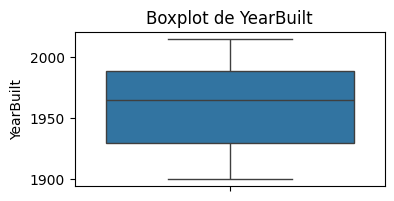

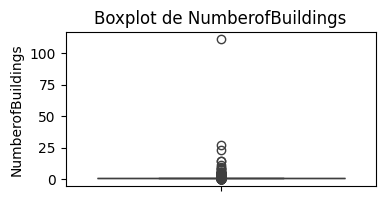

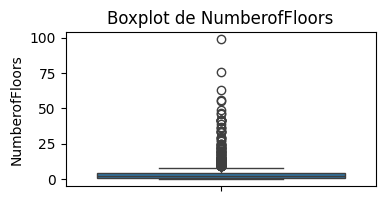

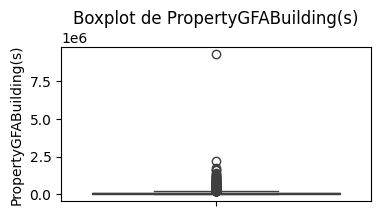

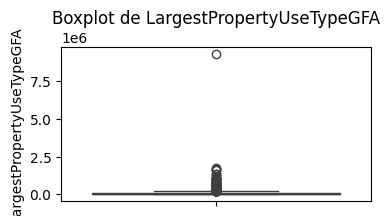

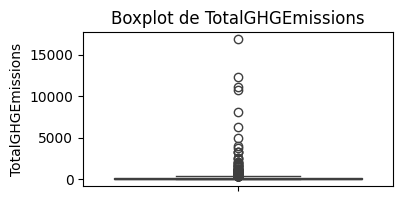

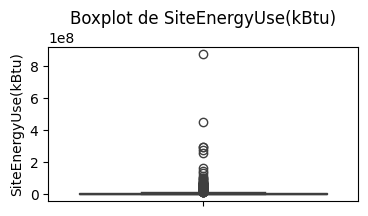

In [120]:
# Créer un boxplot pour chaque colonne
for colonne in colonnes_num:
    plt.figure(figsize=(4, 2))
    sns.boxplot(data=building_consumption_cleaned, y=colonne)
    plt.title(f"Boxplot de {colonne}")
    plt.show()

In [121]:
# Afficher le nombre de lignes avant suppression des outliers
nb_lignes_avant = len(building_consumption_cleaned)
print(f"Nombre de lignes avant suppression des outliers :  {nb_lignes_avant}\n")

# Fonction pour détecter et supprimer les outliers
def compter_supprimer_outliers(df, colonnes):
    outliers_counts = {}
    df_clean = df.copy()

    for colonne in colonnes:
        if colonne in df_clean.select_dtypes(include=[np.number]).columns:
            Q1 = df_clean[colonne].quantile(0.25)
            Q3 = df_clean[colonne].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Compter les outliers
            outliers = ((df_clean[colonne] < lower_bound) | (df_clean[colonne] > upper_bound))
            outliers_counts[colonne] = outliers.sum()

            # Supprimer les outliers
            df_clean = df_clean[~outliers]

    return outliers_counts, df_clean

# Utilisation
outliers_counts, building_consumption_without_outliers = compter_supprimer_outliers(building_consumption_cleaned, colonnes_num)

# Afficher le nombre d'outliers par colonne
print("Nombre d'outliers par colonne :")
for colonne, count in outliers_counts.items():
    print(f"{colonne}: {count}")

# Afficher le nombre de lignes après suppression
nb_lignes_apres = len(building_consumption_without_outliers)
print(f"\nNombre de lignes après suppression des outliers : {nb_lignes_apres}")

Nombre de lignes avant suppression des outliers :  1611

Nombre d'outliers par colonne :
YearBuilt: 0
NumberofBuildings: 103
NumberofFloors: 130
PropertyGFABuilding(s): 131
LargestPropertyUseTypeGFA: 63
TotalGHGEmissions: 126
SiteEnergyUse(kBtu): 58

Nombre de lignes après suppression des outliers : 1000


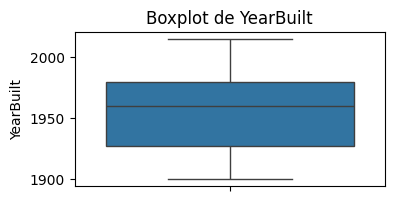

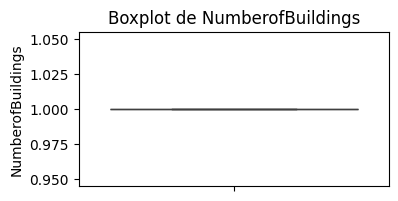

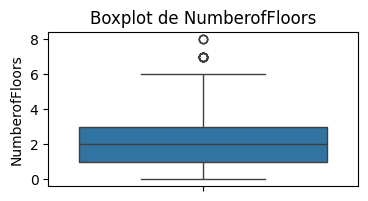

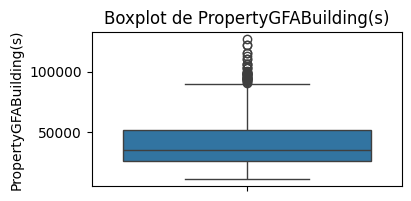

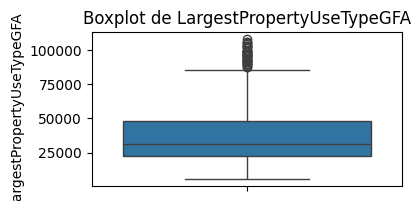

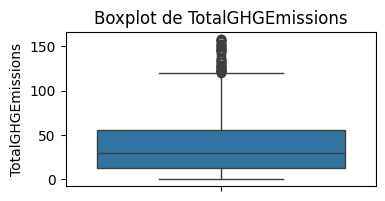

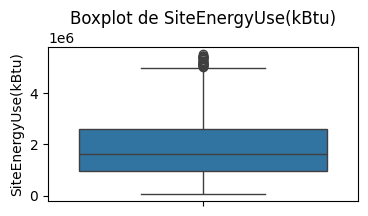

In [122]:
# Créer un boxplot pour chaque colonne
for colonne in colonnes_num:
    plt.figure(figsize=(4, 2))
    sns.boxplot(data=building_consumption_without_outliers, y=colonne)
    plt.title(f"Boxplot de {colonne}")
    plt.show()

In [123]:
# Une seule valeur dans colonne 'NumberofBuildings' donc on supprime
building_consumption_features = building_consumption_without_outliers.drop(columns=['NumberofBuildings'])

In [124]:
# Nombre de type d'usage dans un bâtiment
building_consumption_features['NumberOfPropertyUseTypes'] = building_consumption_features['ListOfAllPropertyUseTypes'].str.split(',').str.len()

# Ajout de l'âge du bâtiment
data_year = building_consumption['DataYear'].drop_duplicates().iloc[0]
building_consumption_features["BuildingAge"] = data_year - building_consumption_features["YearBuilt"]

# Croissement entre l'âge et la surface (grand et ancien = plus énergivore ?)
building_consumption_features["Age_x_Size"] = building_consumption_features["BuildingAge"] * building_consumption_features["PropertyGFABuilding(s)"]

# Surface par étage
building_consumption_features["Floor_density"] = building_consumption_features["PropertyGFABuilding(s)"] / building_consumption_features["NumberofFloors"]

# Surface moyenne par usage principal du bâtiment
mean_size_by_type = building_consumption_features.groupby("LargestPropertyUseType")["PropertyGFABuilding(s)"].mean()
building_consumption_features["size_x_type_mean"] = building_consumption_features["LargestPropertyUseType"].map(mean_size_by_type)

# One Hot Encoding sur l'usage principal
building_consumption_features = pd.get_dummies(building_consumption_features, columns=["PrimaryPropertyType"])

In [125]:
building_consumption_features.head(5)

,YearBuilt,NumberofFloors,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,Latitude,Longitude,ZipCode,CouncilDistrictCode,TotalGHGEmissions,SiteEnergyUse(kBtu),NumberOfPropertyUseTypes,BuildingAge,Age_x_Size,Floor_density,size_x_type_mean,PrimaryPropertyType_Distribution Center,PrimaryPropertyType_Hotel,PrimaryPropertyType_K-12 School,PrimaryPropertyType_Large Office,PrimaryPropertyType_Low-Rise Multifamily,PrimaryPropertyType_Medical Office,PrimaryPropertyType_Mixed Use Property,PrimaryPropertyType_Other,PrimaryPropertyType_Refrigerated Warehouse,PrimaryPropertyType_Residence Hall,PrimaryPropertyType_Restaurant,PrimaryPropertyType_Retail Store,PrimaryPropertyType_Self-Storage Facility,PrimaryPropertyType_Senior Care Community,PrimaryPropertyType_Small- and Mid-Sized Office,PrimaryPropertyType_Supermarket / Grocery Store,PrimaryPropertyType_University,PrimaryPropertyType_Warehouse,PrimaryPropertyType_Worship Facility
22,1961,2,56228,K-12 School,K-12 School,58916.0,47.54576,-122.26853,98118.0,2,38.53,1539478.500,1,55,3092540,28114.000000,49016.500000,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
23,2001,6,58006,"Hotel, Parking",Hotel,58006.0,47.65959,-122.31755,98105.0,4,90.01,3663534.500,2,15,870090,9667.666667,46808.190476,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
25,1930,2,67224,Automobile Dealership,Automobile Dealership,67224.0,47.61500,-122.33081,98101.0,7,9.13,1310236.625,1,86,5781264,33612.000000,49994.000000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
29,1978,5,52210,Hotel,Hotel,47994.0,47.61558,-122.34186,98121.0,7,128.44,4456714.500,1,38,1983980,10442.000000,46808.190476,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32,1906,3,87262,"K-12 School, Multifamily Housing, Office, Othe...",Office,40943.0,47.66410,-122.33118,98070.0,4,157.77,4145920.500,4,110,9598820,29087.333333,43853.043919,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


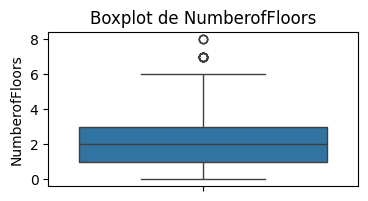

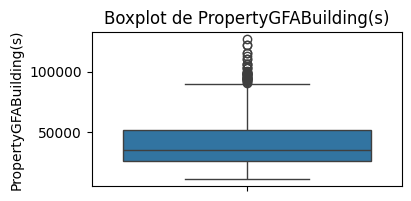

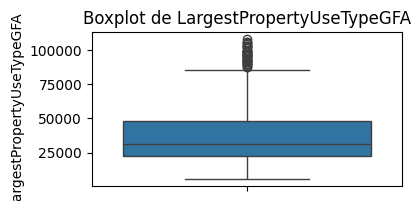

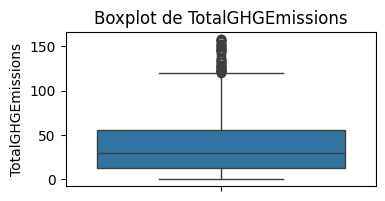

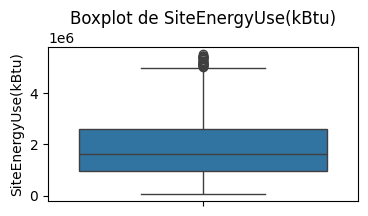

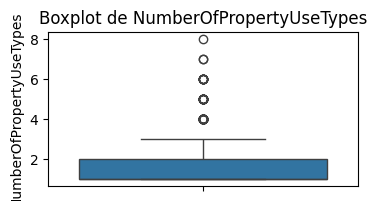

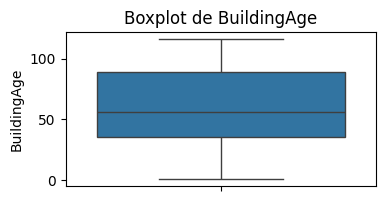

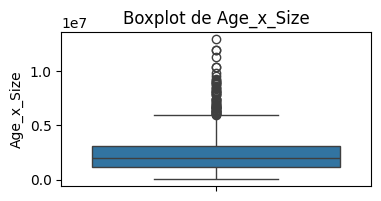

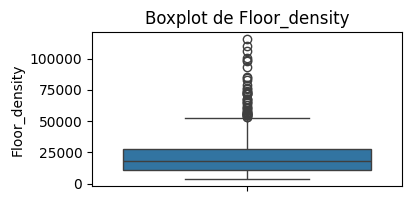

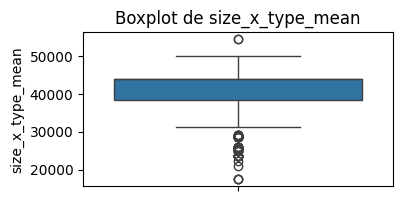

In [126]:
# Liste des colonnes à analyser
features = ['NumberofFloors',
            'PropertyGFABuilding(s)',
            'LargestPropertyUseTypeGFA',
            'TotalGHGEmissions',
            'SiteEnergyUse(kBtu)',
            'NumberOfPropertyUseTypes',
            'BuildingAge',
            'Age_x_Size',
            'Floor_density',
            'size_x_type_mean']

# Créer un boxplot pour chaque colonne
for colonne in features:
    plt.figure(figsize=(4, 2))
    sns.boxplot(data=building_consumption_features, y=colonne)
    plt.title(f"Boxplot de {colonne}")
    plt.show()

In [127]:
# Afficher le nombre de lignes avant suppression des outliers
nb_lignes_avant = len(building_consumption_features)
print(f"Nombre de lignes avant suppression des outliers :  {nb_lignes_avant}\n")

# Fonction pour détecter et supprimer les outliers
def compter_supprimer_outliers(df, colonnes):
    outliers_counts = {}
    df_clean = df.copy()

    for colonne in colonnes:
        if colonne in df_clean.select_dtypes(include=[np.number]).columns:
            Q1 = df_clean[colonne].quantile(0.25)
            Q3 = df_clean[colonne].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Compter les outliers
            outliers = ((df_clean[colonne] < lower_bound) | (df_clean[colonne] > upper_bound))
            outliers_counts[colonne] = outliers.sum()

            # Supprimer les outliers
            df_clean = df_clean[~outliers]

    return outliers_counts, df_clean

# Utilisation
outliers_counts, building_consumption_features_without_outliers = compter_supprimer_outliers(building_consumption_features, features)

# Afficher le nombre d'outliers par colonne
print("Nombre d'outliers par colonne :")
for colonne, count in outliers_counts.items():
    print(f"{colonne}: {count}")

# Afficher le nombre de lignes après suppression
nb_lignes_apres = len(building_consumption_features_without_outliers)
print(f"\nNombre de lignes après suppression des outliers : {nb_lignes_apres}")

Nombre de lignes avant suppression des outliers :  1000

Nombre d'outliers par colonne :
NumberofFloors: 13
PropertyGFABuilding(s): 39
LargestPropertyUseTypeGFA: 19
TotalGHGEmissions: 47
SiteEnergyUse(kBtu): 34
NumberOfPropertyUseTypes: 47
BuildingAge: 0
Age_x_Size: 36
Floor_density: 29
size_x_type_mean: 36

Nombre de lignes après suppression des outliers : 700


In [128]:
# Transformation logarithmique sur la colonne 'PropertyGFABuilding(s)' et 'Age_x_Size' pour éviter une distribution asymétrique
building_consumption_features_without_outliers["PropertyGFABuilding(s)_log"] = np.log(building_consumption_features_without_outliers["PropertyGFABuilding(s)"])
building_consumption_features_without_outliers["Age_x_Size_log"] = np.log(building_consumption_features_without_outliers["Age_x_Size"])

Text(0.5, 1.0, 'Triangle de corrélation')

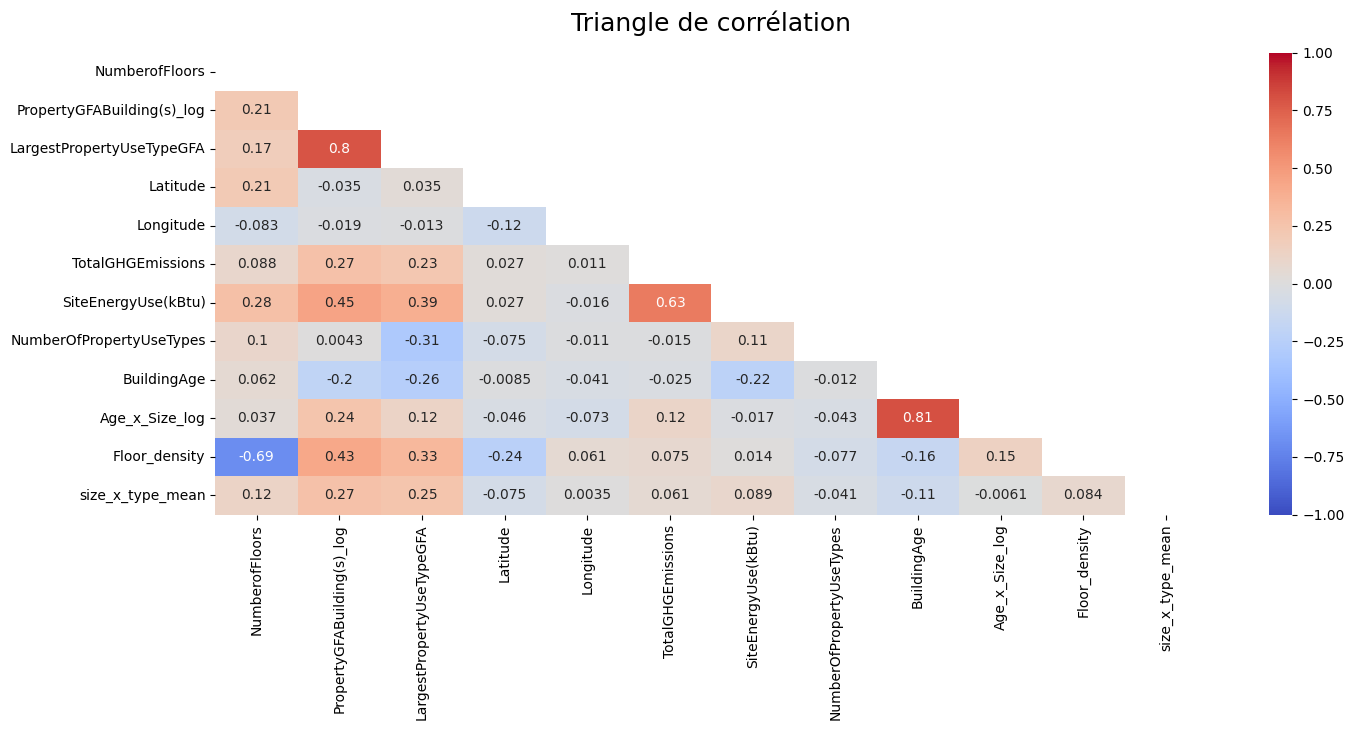

In [129]:
# Variables explicatives
features = ['NumberofFloors',
            'PropertyGFABuilding(s)_log',
            'LargestPropertyUseTypeGFA',
            'Latitude',
            'Longitude',
            'TotalGHGEmissions',
            'SiteEnergyUse(kBtu)',
            'NumberOfPropertyUseTypes',
            'BuildingAge',
            'Age_x_Size_log',
            'Floor_density',
            'size_x_type_mean']

# Matrice de corrélation
mask = np.triu(np.ones_like(building_consumption_features_without_outliers[features].corr()))

# Heatmap général
plt.figure(figsize=(16, 6))
mask = np.triu(np.ones_like(building_consumption_features_without_outliers[features].corr()))
heatmap = sns.heatmap(building_consumption_features_without_outliers[features].corr(), mask=mask, vmin=-1, vmax=1, annot=True, cmap='coolwarm')
heatmap.set_title('Triangle de corrélation', fontdict={'fontsize':18}, pad=16)

In [130]:
# Afficher le nombre de lignes avant suppression
nb_lignes_avant = len(building_consumption_features_without_outliers)
print(f"Nombre de lignes avant suppression des valeurs vides : {nb_lignes_avant}")

# Supprimer les lignes avec des valeurs vides dans n'importe quelle colonne
building_consumption_features_cleaned = building_consumption_features_without_outliers.dropna()

# Afficher le nombre de lignes après suppression
nb_lignes_apres = len(building_consumption_features_cleaned)
print(f"Nombre de lignes après suppression des valeurs vides : {nb_lignes_apres}")

Nombre de lignes avant suppression des valeurs vides : 700
Nombre de lignes après suppression des valeurs vides : 700


In [131]:
building_consumption_features_cleaned.columns

Index(['YearBuilt', 'NumberofFloors', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'Latitude', 'Longitude', 'ZipCode',
       'CouncilDistrictCode', 'TotalGHGEmissions', 'SiteEnergyUse(kBtu)',
       'NumberOfPropertyUseTypes', 'BuildingAge', 'Age_x_Size',
       'Floor_density', 'size_x_type_mean',
       'PrimaryPropertyType_Distribution Center', 'PrimaryPropertyType_Hotel',
       'PrimaryPropertyType_K-12 School', 'PrimaryPropertyType_Large Office',
       'PrimaryPropertyType_Low-Rise Multifamily',
       'PrimaryPropertyType_Medical Office',
       'PrimaryPropertyType_Mixed Use Property', 'PrimaryPropertyType_Other',
       'PrimaryPropertyType_Refrigerated Warehouse',
       'PrimaryPropertyType_Residence Hall', 'PrimaryPropertyType_Restaurant',
       'PrimaryPropertyType_Retail Store',
       'PrimaryPropertyType_Self-Storage Facility',
       'PrimaryPropertyType_Senior Care Community',
       'Pr

In [132]:
# Dataframe pour les features
df_features = building_consumption_features_cleaned[[
            'NumberofFloors',
            'PropertyGFABuilding(s)_log',
            'LargestPropertyUseType', # UNIQUEMENT POUR MAPPER LES DONNÉES D'ENTRAINEMENT DE 'size_x_type_mean'
            'LargestPropertyUseTypeGFA',
            'Latitude',
            'Longitude',
            'NumberOfPropertyUseTypes',
            'BuildingAge',
            'Age_x_Size_log',
            'Floor_density',
            'size_x_type_mean',
            'PrimaryPropertyType_Distribution Center',
            'PrimaryPropertyType_Hotel',
            'PrimaryPropertyType_K-12 School',
            'PrimaryPropertyType_Large Office',
            'PrimaryPropertyType_Low-Rise Multifamily',
            'PrimaryPropertyType_Medical Office',
            'PrimaryPropertyType_Mixed Use Property',
            'PrimaryPropertyType_Other',
            'PrimaryPropertyType_Refrigerated Warehouse',
            'PrimaryPropertyType_Residence Hall',
            'PrimaryPropertyType_Restaurant',
            'PrimaryPropertyType_Retail Store',
            'PrimaryPropertyType_Self-Storage Facility',
            'PrimaryPropertyType_Senior Care Community',
            'PrimaryPropertyType_Small- and Mid-Sized Office',
            'PrimaryPropertyType_Supermarket / Grocery Store',
            'PrimaryPropertyType_University',
            'PrimaryPropertyType_Warehouse',
            'PrimaryPropertyType_Worship Facility',
            'SiteEnergyUse(kBtu)' # UNIQUEMENT POUR LE MODÈLE CO2, À SUPPRIMER DANS LE MODÈLE ENERGY
            ]]

# Dataframe pour la target du modèle "Energy"
df_energy_target = building_consumption_features_cleaned[['SiteEnergyUse(kBtu)']]

# Dataframe pour la target du modèle "CO2"
df_ghg_target = building_consumption_features_cleaned[['TotalGHGEmissions']]

In [133]:
# Liste des DataFrames et des noms de fichiers correspondants
dataframes_to_export = [
    (df_features, 'data/features.csv'),
    (df_energy_target, 'data/energy_target.csv'),
    (df_ghg_target, 'data/ghg_target.csv')
]

# Boucle pour exporter chaque DataFrame
for df, file_path in dataframes_to_export:
    df.to_csv(file_path, index=False)